# Fetal Health Classification: End-to-End Machine Learning Project

This notebook develops a reproducible multiclass classifier for fetal health using cardiotocography measurements. It covers data-quality checks, exploratory analysis, leakage-safe model comparison, hyperparameter optimization, experiment tracking, final evaluation, interpretation, and model persistence.

**Target classes**

- `1` — Normal
- `2` — Suspect
- `3` — Pathological

> This project is for educational and research purposes. A model trained on this public dataset must not be used for clinical decisions without external validation, calibration assessment, governance, and review by qualified healthcare professionals.

## 1. Modeling principles

The workflow follows four rules:

1. Remove exact duplicate rows before splitting to reduce leakage risk.
2. Create one stratified holdout test set and leave it untouched until the final model is selected.
3. Compare baseline models using five-fold stratified cross-validation on the training set only.
4. Optimize **macro F1-score**, because accuracy can hide poor performance on the smaller Suspect and Pathological classes.

The final test set is used once to estimate generalization performance.

## 2. Setup and dependencies

Required libraries are `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `lightgbm`, `optuna`, `mlflow`, and `joblib`.

If needed, install the additional packages with:

```bash
pip install lightgbm optuna mlflow
```

In [1]:
from pathlib import Path
import json
import platform
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn

from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_TRIALS = 20

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "fetal_health.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"Python:       {platform.python_version()}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"LightGBM:     {lgb.__version__}")
print(f"Optuna:       {optuna.__version__}")
print(f"MLflow:       {mlflow.__version__}")
print(f"Data path:    {DATA_PATH}")

Python:       3.11.3
scikit-learn: 1.9.0
LightGBM:     4.7.0
Optuna:       4.9.0
MLflow:       3.14.0
Data path:    C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\data\raw\fetal_health.csv


## 3. Load and validate the data

The initial audit checks dimensions, data types, missing values, exact duplicates, target validity, and class balance. These checks make silent data problems visible before modeling.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

TARGET = "fetal_health"
EXPECTED_TARGETS = {1, 2, 3}

assert TARGET in df_raw.columns, f"Missing target column: {TARGET}"
assert df_raw.shape[1] == 22, "Unexpected number of columns"
assert set(df_raw[TARGET].dropna().astype(int).unique()) == EXPECTED_TARGETS, "Unexpected target labels"

audit = pd.Series({
    "rows": len(df_raw),
    "predictors": df_raw.shape[1] - 1,
    "missing_values": int(df_raw.isna().sum().sum()),
    "exact_duplicate_rows": int(df_raw.duplicated().sum()),
})

display(audit.to_frame("value"))
display(df_raw.head())

,value
rows,2126
predictors,21
missing_values,0
exact_duplicate_rows,13


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


,count,percentage
class,,
1,1655,77.85%
2,295,13.88%
3,176,8.28%


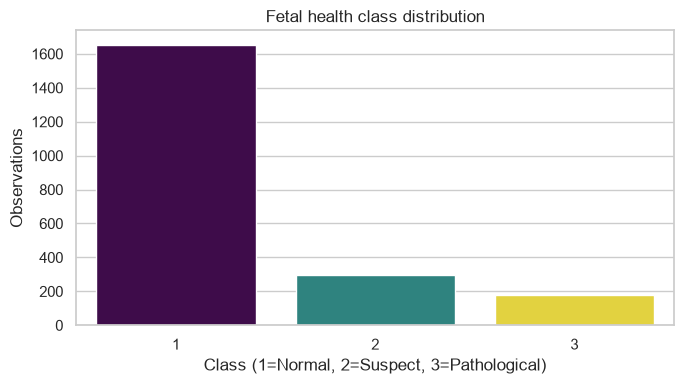

In [3]:
class_summary = (
    df_raw[TARGET]
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("class")
    .to_frame("count")
)
class_summary["percentage"] = 100 * class_summary["count"] / class_summary["count"].sum()
display(class_summary.style.format({"percentage": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_raw.assign(fetal_health=df_raw[TARGET].astype(int)), x=TARGET, hue=TARGET, palette="viridis", legend=False, ax=ax)
ax.set_title("Fetal health class distribution")
ax.set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
ax.set_ylabel("Observations")
plt.tight_layout()
plt.show()

## 4. Clean the modeling table

There are no missing values, so imputation is unnecessary. Exact duplicate rows are removed before splitting; otherwise identical records could appear in both training and test data and make performance look overly optimistic.

In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True).copy()
df[TARGET] = df[TARGET].astype(int)

X = df.drop(columns=TARGET)
y = df[TARGET]

assert not X.isna().any().any()
assert X.select_dtypes(exclude=np.number).empty
assert X.index.equals(y.index)

print(f"Rows before duplicate removal: {len(df_raw):,}")
print(f"Rows after duplicate removal:  {len(df):,}")
print(f"Predictor matrix:              {X.shape}")

Rows before duplicate removal: 2,126
Rows after duplicate removal:  2,113
Predictor matrix:              (2113, 21)


## 5. Focused exploratory analysis

The correlation view is descriptive rather than causal. It identifies variables associated with the ordinal target, but model evaluation remains the basis for selecting a predictive algorithm.

,correlation_with_target
prolongued_decelerations,0.486752
abnormal_short_term_variability,0.469671
percentage_of_time_with_abnormal_long_term_variability,0.421634
accelerations,-0.363947
histogram_mode,-0.253612
histogram_mean,-0.230243
mean_value_of_long_term_variability,-0.225685
histogram_median,-0.208334
histogram_variance,0.208171
uterine_contractions,-0.205117


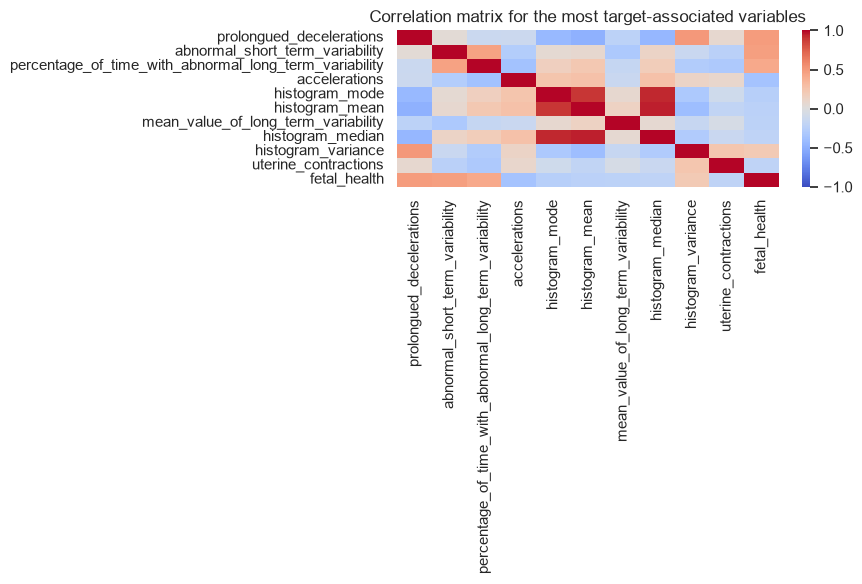

In [5]:
target_correlations = (
    df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

display(target_correlations.to_frame("correlation_with_target").head(12))

top_features = target_correlations.abs().head(10).index
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    df[list(top_features) + [TARGET]].corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlation matrix for the most target-associated variables")
plt.tight_layout()
plt.show()

## 6. Stratified train/test split

Stratification preserves the target proportions in both partitions. All model selection and tuning below use only `X_train` and `y_train`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_balance = pd.concat(
    {
        "full": y.value_counts(normalize=True).sort_index(),
        "train": y_train.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    },
    axis=1,
)

print(f"Training shape: {X_train.shape}")
print(f"Test shape:     {X_test.shape}")
display(split_balance.style.format("{:.2%}"))

Training shape: (1690, 21)
Test shape:     (423, 21)


,full,train,test
fetal_health,,,
1,77.90%,77.87%,78.01%
2,13.82%,13.85%,13.71%
3,8.28%,8.28%,8.27%


## 7. Baseline model comparison

The benchmark includes a dummy reference, linear model, single tree, bagged tree ensembles, histogram gradient boosting, and LightGBM. Logistic regression is placed in a scaling pipeline to prevent preprocessing leakage inside cross-validation. Tree-based models do not require feature scaling.

Models are ranked by mean cross-validated macro F1. Balanced accuracy and ordinary accuracy are retained as supporting metrics.

In [7]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Dummy (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(
        objective="multiclass",
        n_estimators=200,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),
}

scoring = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

baseline_rows = []
for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    baseline_rows.append({
        "model": model_name,
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "fit_time_seconds": scores["fit_time"].mean(),
    })

baseline_results = (
    pd.DataFrame(baseline_rows)
    .set_index("model")
    .sort_values("macro_f1_mean", ascending=False)
)

display(baseline_results.style.format("{:.4f}"))

C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,accuracy_mean,fit_time_seconds
model,,,,,
LightGBM,0.9014,0.0237,0.8895,0.9450,0.8689
Histogram Gradient Boosting,0.8972,0.0193,0.8847,0.9444,1.8236
Random Forest,0.8835,0.0195,0.8954,0.9302,0.7737
Extra Trees,0.8606,0.0146,0.8348,0.9278,0.6759
Decision Tree,0.8435,0.0158,0.8429,0.9095,0.0126
Logistic Regression,0.7807,0.0298,0.8501,0.8639,0.0742
Dummy (majority class),0.2919,0.0002,0.3333,0.7787,0.0024


Selected baseline: LightGBM
Mean CV macro F1:  0.9014


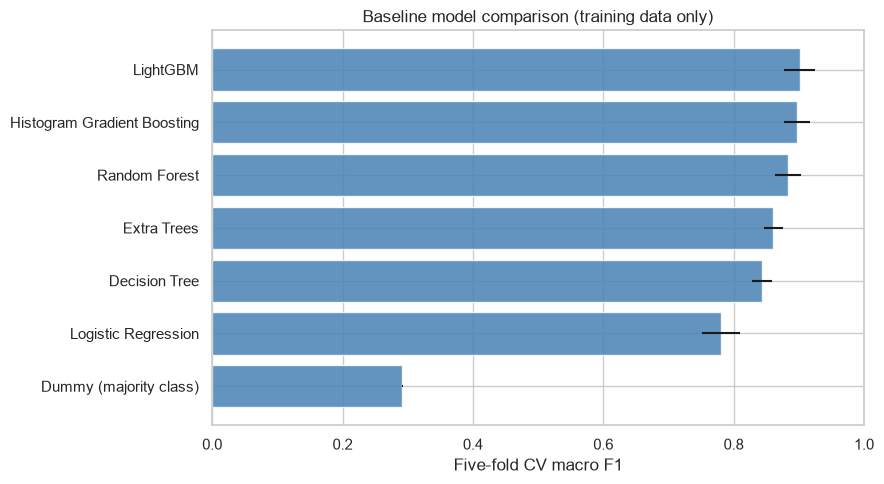

In [8]:
best_baseline_name = baseline_results.index[0]
best_baseline_cv_f1 = baseline_results.iloc[0]["macro_f1_mean"]

print(f"Selected baseline: {best_baseline_name}")
print(f"Mean CV macro F1:  {best_baseline_cv_f1:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = baseline_results.sort_values("macro_f1_mean")
ax.barh(plot_data.index, plot_data["macro_f1_mean"], xerr=plot_data["macro_f1_std"], color="steelblue", alpha=0.85)
ax.set_xlabel("Five-fold CV macro F1")
ax.set_title("Baseline model comparison (training data only)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

assert best_baseline_name == "LightGBM", (
    "The strongest baseline changed in this environment. Review the ranking and tune the new winner."
)

## 8. Hyperparameter optimization with Optuna

LightGBM is tuned because it achieved the strongest baseline cross-validated macro F1. Optuna's seeded TPE sampler searches tree complexity, learning rate, sampling, and regularization parameters. Every trial is evaluated with the same five stratified folds.

MLflow records the parameters and validation metrics for every trial. The test set is still not used.

In [9]:
TRACKING_DB = (ARTIFACT_DIR / "mlflow_fetal_health.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DB.as_posix()}")
mlflow.set_experiment("Fetal Health - Professional LightGBM")

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 12)
    params = {
        "objective": "multiclass",
        "n_estimators": trial.suggest_int("n_estimators", 150, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 7, min(127, 2**max_depth)),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }

    candidate = LGBMClassifier(**params)
    scores = cross_validate(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    trial_metrics = {
        "cv_macro_f1": float(scores["test_macro_f1"].mean()),
        "cv_balanced_accuracy": float(scores["test_balanced_accuracy"].mean()),
        "cv_accuracy": float(scores["test_accuracy"].mean()),
        "cv_macro_f1_std": float(scores["test_macro_f1"].std()),
    }

    with mlflow.start_run(run_name=f"optuna_trial_{trial.number:03d}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metrics(trial_metrics)

    return trial_metrics["cv_macro_f1"]

In [10]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="optuna_lightgbm_tuning") as tuning_run:
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_metric("best_cv_macro_f1", study.best_value)
    mlflow.log_params({f"best_{key}": value for key, value in study.best_params.items()})

print(f"Completed trials:     {len(study.trials)}")
print(f"Baseline CV macro F1: {best_baseline_cv_f1:.4f}")
print(f"Tuned CV macro F1:    {study.best_value:.4f}")
print(f"CV improvement:       {study.best_value - best_baseline_cv_f1:+.4f}")
print("\nBest parameters:")
display(pd.Series(study.best_params, name="value").to_frame())

  0%|          | 0/20 [00:00<?, ?it/s]

Completed trials:     20
Baseline CV macro F1: 0.9014
Tuned CV macro F1:    0.9020
CV improvement:       +0.0006

Best parameters:


,value
max_depth,10.000000
n_estimators,305.000000
learning_rate,0.019308
num_leaves,92.000000
min_child_samples,5.000000
subsample,0.789709
colsample_bytree,0.724570
reg_alpha,0.003080
reg_lambda,0.000247
min_split_gain,0.140009


,number,value,state
16,16,0.902007,COMPLETE
2,2,0.900332,COMPLETE
15,15,0.898964,COMPLETE
11,11,0.897216,COMPLETE
9,9,0.896072,COMPLETE
1,1,0.895952,COMPLETE
12,12,0.895589,COMPLETE
17,17,0.895027,COMPLETE
19,19,0.891821,COMPLETE
8,8,0.891020,COMPLETE


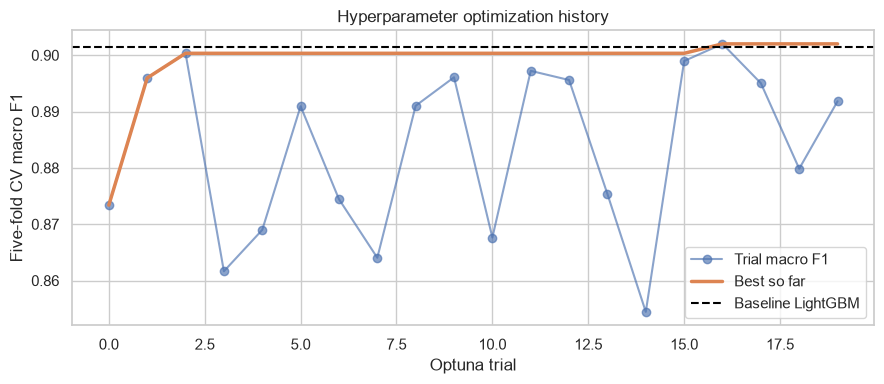

In [11]:
trials_df = study.trials_dataframe()
trial_history = trials_df[["number", "value", "state"]].copy()
display(trial_history.sort_values("value", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(trial_history["number"], trial_history["value"], marker="o", alpha=0.65, label="Trial macro F1")
ax.plot(trial_history["number"], trial_history["value"].cummax(), linewidth=2.5, label="Best so far")
ax.axhline(best_baseline_cv_f1, color="black", linestyle="--", label="Baseline LightGBM")
ax.set_xlabel("Optuna trial")
ax.set_ylabel("Five-fold CV macro F1")
ax.set_title("Hyperparameter optimization history")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Final model and untouched test evaluation

The best hyperparameters are now fitted to the full training partition. This is the first point at which the holdout test set is used. Results include ordinary accuracy, balanced accuracy, macro F1, macro recall, per-class metrics, and a confusion matrix.

In [12]:
best_params = {
    **study.best_params,
    "objective": "multiclass",
    "subsample_freq": 1,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

best_model = LGBMClassifier(**best_params)

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="final_tuned_lightgbm") as final_run:
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test).astype(int)

    final_metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
        "test_macro_recall": recall_score(y_test, y_pred, average="macro"),
    }

    mlflow.log_params(best_params)
    mlflow.log_metrics(final_metrics)
    mlflow.log_dict(
        classification_report(y_test, y_pred, output_dict=True, zero_division=0),
        "classification_report.json",
    )
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="model",
        input_example=X_train.head(5),
        skops_trusted_types=[
            "collections.OrderedDict",
            "lightgbm.basic.Booster",
            "lightgbm.sklearn.LGBMClassifier",
        ],
    )

display(pd.Series(final_metrics, name="score").to_frame().style.format("{:.4f}"))
print(classification_report(
    y_test,
    y_pred,
    labels=[1, 2, 3],
    target_names=["Normal", "Suspect", "Pathological"],
    digits=4,
    zero_division=0,
))

C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


,score
test_accuracy,0.9622
test_balanced_accuracy,0.9223
test_macro_f1,0.9295
test_macro_recall,0.9223


              precision    recall  f1-score   support

      Normal     0.9703    0.9909    0.9805       330
     Suspect     0.9375    0.7759    0.8491        58
Pathological     0.9211    1.0000    0.9589        35

    accuracy                         0.9622       423
   macro avg     0.9430    0.9223    0.9295       423
weighted avg     0.9617    0.9622    0.9607       423



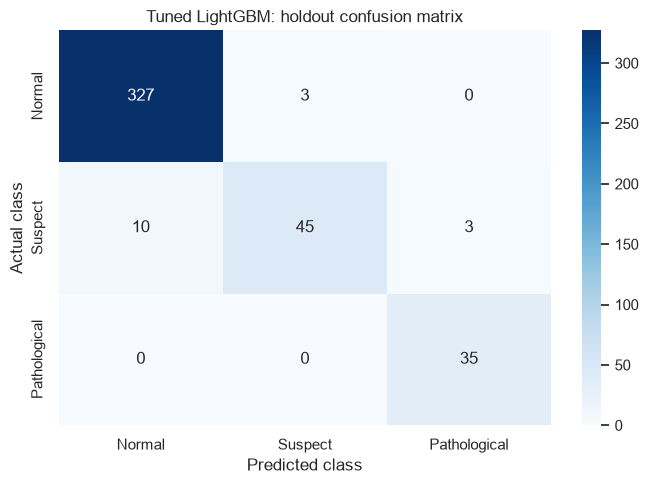

In [13]:
labels = [1, 2, 3]
class_names = ["Normal", "Suspect", "Pathological"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Tuned LightGBM: holdout confusion matrix")
plt.tight_layout()
plt.show()

## 10. Model interpretation

Permutation importance measures the reduction in holdout macro F1 after each feature is randomly shuffled. Unlike built-in split importance, it is expressed in terms of the selected evaluation metric. Importance does not establish causality.

,feature,importance_mean,importance_std
7,abnormal_short_term_variability,0.1543,0.0205
1,accelerations,0.0990,0.0115
9,percentage_of_time_with_abnormal_long_term_variability,0.0714,0.0155
17,histogram_mean,0.0387,0.0076
0,baseline value,0.0213,0.0075
18,histogram_median,0.0157,0.0076
3,uterine_contractions,0.0131,0.0056
6,prolongued_decelerations,0.0088,0.0082
8,mean_value_of_short_term_variability,0.0079,0.0043
14,histogram_number_of_peaks,0.0067,0.0049


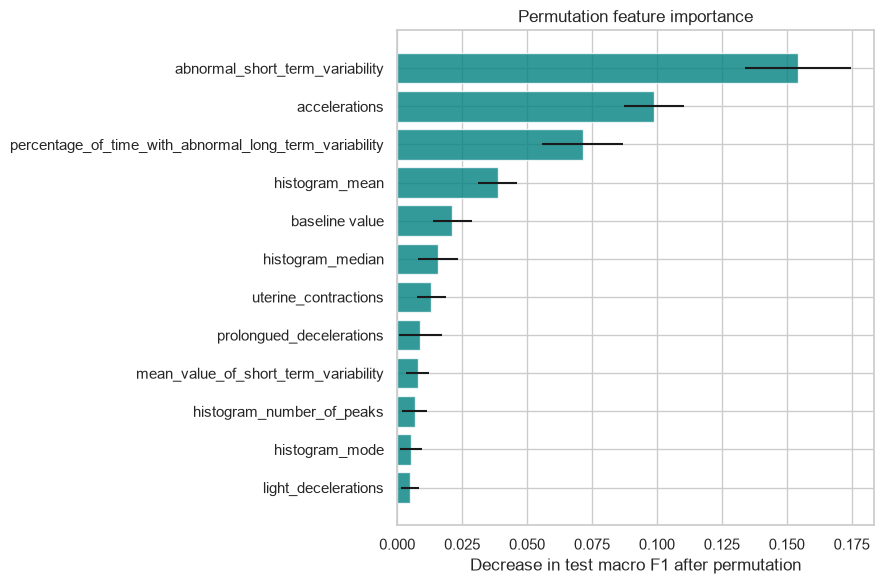

In [14]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

display(importance.head(15).style.format({
    "importance_mean": "{:.4f}",
    "importance_std": "{:.4f}",
}))

top_importance = importance.head(12).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color="teal",
    alpha=0.8,
)
ax.set_xlabel("Decrease in test macro F1 after permutation")
ax.set_title("Permutation feature importance")
plt.tight_layout()
plt.show()

## 11. Persist the model and metadata

The fitted estimator is saved with its feature order, class mapping, selected hyperparameters, and evaluation metrics. Keeping this metadata with the model reduces inference-time mistakes.

In [15]:
MODEL_PATH = ARTIFACT_DIR / "best_fetal_health_lightgbm.joblib"
METADATA_PATH = ARTIFACT_DIR / "best_fetal_health_lightgbm_metadata.json"

joblib.dump(best_model, MODEL_PATH)

metadata = {
    "target": TARGET,
    "class_mapping": {"1": "Normal", "2": "Suspect", "3": "Pathological"},
    "feature_order": X.columns.tolist(),
    "random_state": RANDOM_STATE,
    "best_cv_macro_f1": float(study.best_value),
    "test_metrics": {key: float(value) for key, value in final_metrics.items()},
    "best_params": study.best_params,
    "mlflow_run_id": final_run.info.run_id,
}

METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved model:    {MODEL_PATH}")
print(f"Saved metadata: {METADATA_PATH}")
print(f"MLflow store:   {TRACKING_DB}")

Saved model:    C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\artifacts\best_fetal_health_lightgbm.joblib
Saved metadata: C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\artifacts\best_fetal_health_lightgbm_metadata.json
MLflow store:   C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Fetal Health Classifier(PJ 4)\artifacts\mlflow_fetal_health.db
